In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import mca
import prince
from scipy.stats import chi2_contingency
import plotly.express as px
import plotly.io as pio
import altair as alt
from sklearn.cluster import KMeans
from bokeh.plotting import figure, show, output_notebook
pio.renderers.default = "png"
output_notebook()


Loading BokehJS ...

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime

# Carga de datos
datos_total = pd.read_excel('Proyecto/Consolidado.xlsx')
datos_total.columns = [col.strip() for col in datos_total.columns]

# Cálculo de variables faltantes
birth_col = "TO_CHAR(E.FECHANACIMIENTO,'DD-MM-YYYY')"
if birth_col not in datos_total.columns and birth_col + ' ' in datos_total.columns:
    birth_col = birth_col + ' '

datos_total['birth_date'] = pd.to_datetime(datos_total[birth_col], unit='D', origin='1899-12-30')
reference_date = pd.to_datetime('2022-01-01')
datos_total['EDAD'] = datos_total['birth_date'].apply(lambda x: reference_date.year - x.year - ((reference_date.month, reference_date.day) < (x.month, x.day)))
datos_total['FEMENINO'] = datos_total['SEXO'].apply(lambda x: 1 if str(x).strip().upper() == 'F' else 0)

bins = [0, 18, 25, 35, 45, 55, 65, 120]
labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '66+']
datos_total['RANGO DE EDAD'] = pd.cut(datos_total['EDAD'], bins=bins, labels=labels)

if 'INICIO_OCURRENCIA' in datos_total.columns:
    datos_total['FECHA INICIAL'] = datos_total['INICIO_OCURRENCIA']

print('Variables preprocesadas correctamente.')

Variables preprocesadas correctamente.


In [3]:
datos_total.head()

,CEDULA,TIPO,SUBTIPO,INICIO_OCURRENCIA,DIA DE LA SEMANA,DIAS HABILES,SEXO,CODCARGOEMPRESA,CARGOEMPRESA,CODCARGO,...,SITUACIONLABORAL,CODDEPENDENCIA,DEPENDENCIA,DIRECCION,CODCIUDADRESIDENCIA,birth_date,EDAD,FEMENINO,RANGO DE EDAD,FECHA INICIAL
0,52328786,1,2,2021-03-25,5,55,F,9001.0,Docente de aula,900.0,...,Normal,C256580011502,CONCENTARCION URBANA ANTONIA SANTOS (Primaria),CALLE 3 # 3-60,25154.0,1974-09-24,47.0,1,46-55,2021-03-25
1,41570594,1,2,2021-08-12,5,60,F,9001.0,Docente de aula,900.0,...,Normal,C258170020402,ESCUELA RURAL LA ESMERALDA (Primaria),KRA 38 # 2C-11,11001.0,1952-07-25,69.0,1,66+,2021-08-12
2,39727960,1,1,2021-10-09,7,21,F,9001.0,Docente de aula,900.0,...,Normal,C251510010502,ESCUELA URBANA CARLOS JOSE ROMERO (Primaria),CLL 3 N 5-03,25151.0,1965-04-29,56.0,1,56-65,2021-10-09
3,52982139,1,1,2021-09-07,3,29,F,9001.0,Docente de aula,900.0,...,Normal,C251200012002,ESC. RURAL ALTO ARIARI 2 (Primaria),VEREDA EL TAPAZ FINCA LA VIRGEN EL PEÑON,25258.0,1983-03-23,38.0,1,36-45,2021-09-07
4,79694188,1,2,2021-08-05,5,30,M,9003.0,Docente Orientador,900.0,...,Normal,C2549100301,I.E. DEPARTAMENTAL NORMAL SUPERIOR - SEDE PRIN...,CARRERA 102 N° 155B - 03 TORRE 8 APT 204,11001.0,1975-08-28,46.0,0,46-55,2021-08-05


In [4]:
datos_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 7234 entries, 0 to 7233
Data columns (total 49 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   CEDULA                                       7234 non-null   int64         
 1   TIPO                                         7234 non-null   int64         
 2   SUBTIPO                                      7234 non-null   int64         
 3   INICIO_OCURRENCIA                            7234 non-null   datetime64[us]
 4   DIA DE LA SEMANA                             7234 non-null   int64         
 5   DIAS HABILES                                 7234 non-null   int64         
 6   SEXO                                         7167 non-null   str           
 7   CODCARGOEMPRESA                              7167 non-null   float64       
 8   CARGOEMPRESA                                 7167 non-null   str           
 9   CODCARGO

In [5]:
tabla_contingencia = pd.crosstab(datos_total['EDAD'], [datos_total['TIPO'], datos_total['SUBTIPO'], datos_total['FEMENINO']], margins=True)

In [6]:
tabla_contingencia

TIPO        1                          2               ...                 \
SUBTIPO     1         2         3  4   6       7    8  ... 17 18       19   
FEMENINO    0     1   0    1    1  0   0    1  1    0  ...  1  0   1    0   
EDAD                                                   ...                  
20.0        0     0   0    0    0  0   0    0  0    0  ...  0  0   0    0   
23.0        0     0   0    0    0  0   0    0  0    0  ...  0  0   0    0   
24.0        0     0   0    0    0  0   0    0  0    1  ...  0  0   0    0   
25.0        0     0   1    0    0  0   0    1  0    0  ...  0  0   0    0   
26.0        1     5   0    0    0  0   0    0  0    4  ...  0  0   0    0   
27.0        1     4   0    2    3  0   0    0  0    0  ...  0  0   0    0   
28.0        0     5   0    0    1  0   1    0  0    5  ...  1  0   0    0   
29.0        2    10   0    2   10  0   0    2  0    0  ...  0  0   1    0   
30.0        4    12   0    0   10  0   0    0  0    4  ...  0  0   0    5   
31.0        3     4   0    1    7  0   0    4  0    5  ...  0  0   0    2   
32.0        2    13   0    1    7  0   0    1  0   11  ...  0  0   0    0   
33.0       10    24   1    3   12  0   0    0  0   12  ...  0  0   0    4   
34.0        8    17   0   12    9  0   1    4  0   19  ...  0  0   0    3   
35.0       33    33   2    8   14  0   2    4  0   10  ...  0  0   0    1   
36.0        3    20   2    2    9  0   2    1  0    7  ...  0  0   0    5   
37.0       13    27   6    2   14  0   2    5  0   14  ...  0  0   1    3   
38.0        8    36   3    1    7  1   2    3  0    5  ...  0  0   0    1   
39.0        5    31   0    6    6  0   1    1  0    6  ...  0  0   2    2   
40.0       16    44   0   23    8  0   5    2  0    7  ...  0  0   1    5   
41.0       12    33  14    8    4  0   2    4  0   21  ...  0  0   2    8   
42.0        6    61   4   10    7  0   3   10  0   17  ...  0  0   0    8   
43.0        9    25   0    2    2  0   1    3  0   15  ...  0  0   0    3   
44.0        6    14   0    7    0  0   1    2  0   11  ...  0  0   0   14   
45.0        7    28   1   20    1  0   2    2  0    8  ...  0  0   0    4   
46.0        5    14  12   19    0  0   3    6  0   28  ...  0  0   0    1   
47.0       15    28   6    9    0  0   0    3  0    9  ...  0  0   0    5   
48.0        4    18   0   14    0  0   0    8  0   11  ...  0  0   0    3   
49.0        5    54   0   18    0  0   5    1  0   15  ...  0  0   1    6   
50.0        4    61   7   30    0  0   0    2  0   10  ...  0  0   1    0   
51.0       13    22   0    7    0  0   0    2  0    4  ...  0  0   0    2   
52.0        4    19   8   31    0  0   1    3  0   12  ...  0  0   1    0   
53.0        1    31   0   23    0  0   2    5  0    6  ...  0  1   0    5   
54.0       12    56   1   13    0  0   2    4  0    6  ...  0  1   1    2   
55.0        8    36   2    2    0  0   1    4  0   16  ...  0  0   0    1   
56.0        4    40   1   13    0  0   0    8  0    3  ...  0  0   1    1   
57.0        5    26   0    6    0  0   3    4  0   13  ...  0  2   0    4   
58.0       14    30   0   17    0  0   1    1  0    6  ...  0  0   0    1   
59.0       15    37   3   30    0  0   3    4  0    8  ...  0  0   1    4   
60.0       17    18   1    6    0  0   1    4  1   10  ...  0  0   1    2   
61.0        1    69   0    4    0  0   3    5  0   11  ...  0  0   0    3   
62.0        0    41   0   11    0  0   1    0  0    5  ...  0  0   0    2   
63.0        4    47   0    1    0  0   1    3  0    6  ...  0  0   0    1   
64.0       18    28   4    4    0  0   0    1  0   15  ...  0  0   0    2   
65.0        6    54   4    2    0  0   2    2  0    9  ...  0  0   0    3   
66.0        8    31   0   16    0  0   1    0  0    2  ...  0  0   0    0   
67.0       14     6  11   10    0  0   1    2  0    7  ...  0  0   0    3   
68.0        0     5   0    1    0  0   0    0  0    1  ...  0  0   0    0   
69.0        9     2   0    7    0  0   0    2  0   11  ...  0  0   0    0

In [7]:
#Tabla de contingencia relativa
tabla_contingencia_r = pd.crosstab(index=datos_total['EDAD'], columns=([datos_total['TIPO'], datos_total['SUBTIPO'], datos_total['FEMENINO']]),
            margins=True).apply(lambda r: r/len(datos_total) *100,
                                axis=1)
tabla_contingencia_r

TIPO             1                                                     \
SUBTIPO          1                    2                   3         4   
FEMENINO         0          1         0         1         1         0   
EDAD                                                                    
20.0      0.000000   0.000000  0.000000  0.000000  0.000000  0.000000   
23.0      0.000000   0.000000  0.000000  0.000000  0.000000  0.000000   
24.0      0.000000   0.000000  0.000000  0.000000  0.000000  0.000000   
25.0      0.000000   0.000000  0.013824  0.000000  0.000000  0.000000   
26.0      0.013824   0.069118  0.000000  0.000000  0.000000  0.000000   
27.0      0.013824   0.055294  0.000000  0.027647  0.041471  0.000000   
28.0      0.000000   0.069118  0.000000  0.000000  0.013824  0.000000   
29.0      0.027647   0.138236  0.000000  0.027647  0.138236  0.000000   
30.0      0.055294   0.165883  0.000000  0.000000  0.138236  0.000000   
31.0      0.041471   0.055294  0.000000  0.013824  0.096765  0.000000   
32.0      0.027647   0.179707  0.000000  0.013824  0.096765  0.000000   
33.0      0.138236   0.331767  0.013824  0.041471  0.165883  0.000000   
34.0      0.110589   0.235001  0.000000  0.165883  0.124412  0.000000   
35.0      0.456179   0.456179  0.027647  0.110589  0.193531  0.000000   
36.0      0.041471   0.276472  0.027647  0.027647  0.124412  0.000000   
37.0      0.179707   0.373237  0.082942  0.027647  0.193531  0.000000   
38.0      0.110589   0.497650  0.041471  0.013824  0.096765  0.013824   
39.0      0.069118   0.428532  0.000000  0.082942  0.082942  0.000000   
40.0      0.221178   0.608239  0.000000  0.317943  0.110589  0.000000   
41.0      0.165883   0.456179  0.193531  0.110589  0.055294  0.000000   
42.0      0.082942   0.843240  0.055294  0.138236  0.096765  0.000000   
43.0      0.124412   0.345590  0.000000  0.027647  0.027647  0.000000   
44.0      0.082942   0.193531  0.000000  0.096765  0.000000  0.000000   
45.0      0.096765   0.387061  0.013824  0.276472  0.013824  0.000000   
46.0      0.069118   0.193531  0.165883  0.262649  0.000000  0.000000   
47.0      0.207354   0.387061  0.082942  0.124412  0.000000  0.000000   
48.0      0.055294   0.248825  0.000000  0.193531  0.000000  0.000000   
49.0      0.069118   0.746475  0.000000  0.248825  0.000000  0.000000   
50.0      0.055294   0.843240  0.096765  0.414708  0.000000  0.000000   
51.0      0.179707   0.304119  0.000000  0.096765  0.000000  0.000000   
52.0      0.055294   0.262649  0.110589  0.428532  0.000000  0.000000   
53.0      0.013824   0.428532  0.000000  0.317943  0.000000  0.000000   
54.0      0.165883   0.774122  0.013824  0.179707  0.000000  0.000000   
55.0      0.110589   0.497650  0.027647  0.027647  0.000000  0.000000   
56.0      0.055294   0.552944  0.013824  0.179707  0.000000  0.000000   
57.0      0.069118   0.359414  0.000000  0.082942  0.000000  0.000000   
58.0      0.193531   0.414708  0.000000  0.235001  0.000000  0.000000   
59.0      0.207354   0.511474  0.041471  0.414708  0.000000  0.000000   
60.0      0.235001   0.248825  0.013824  0.082942  0.000000  0.000000   
61.0      0.013824   0.953829  0.000000  0.055294  0.000000  0.000000   
62.0      0.000000   0.566768  0.000000  0.152060  0.000000  0.000000   
63.0      0.055294   0.649710  0.000000  0.013824  0.000000  0.000000   
64.0      0.248825   0.387061  0.055294  0.055294  0.000000  0.000000   
65.0      0.082942   0.746475  0.055294  0.027647  0.000000  0.000000   
66.0      0.110589   0.428532  0.000000  0.221178  0.000000  0.000000   
67.0      0.193531   0.082942  0.152060  0.138236  0.000000  0.000000   
68.0      0.000000   0.069118  0.000000  0.013824  0.000000  0.000000   
69.0      0.124412   0.027647  0.000000  0.096765  0.000000  0.000000   
70.0      0.082942   0.000000  0.000000  0.000000  0.000000  0.000000   
71.0      0.055294   0.000000  0.000000  0.000000  0.000000  0.000000   
All       4.769146  16.850981  1.299419  5.584739  1.81089

In [8]:
# Utilizamos la función chi2_contingency para calcular el índice de Chi-cuadrado y el p-valor
chi2, p, dof, expected = chi2_contingency(tabla_contingencia.drop('All', axis=0).drop('All', axis=1, level=0))
# Si el p-valor es menor que 0.05, podemos decir que existe una relación significativa entre las variables
if p < 0.05:
    print("Existe una relación significativa entre las variables (p = {})".format(p))
else:
    print("No existe una relación significativa entre las variables (p = {})".format(p))

Existe una relación significativa entre las variables (p = 2.4040989955492e-173)


In [9]:
# Calcula el indicador de asociación Phi de Pearson
a = tabla_contingencia.iloc[0, 0]
b = tabla_contingencia.iloc[0, 1]
c = tabla_contingencia.iloc[0, 2]
d = tabla_contingencia.iloc[0, 3]

try:
   # Calcula el indicador de asociación Phi de Pearson
   phi = (a * d - b * c) / ((a + b) * (c + d))**0.5
except ZeroDivisionError:
   # Maneja la excepción de división por cero
   print("Se ha producido una división por cero")
# phi = None

/tmp/ipykernel_539145/3529258371.py:9: RuntimeWarning: invalid value encountered in scalar divide
  phi = (a * d - b * c) / ((a + b) * (c + d))**0.5


In [10]:
dat=datos_total.to_numpy()

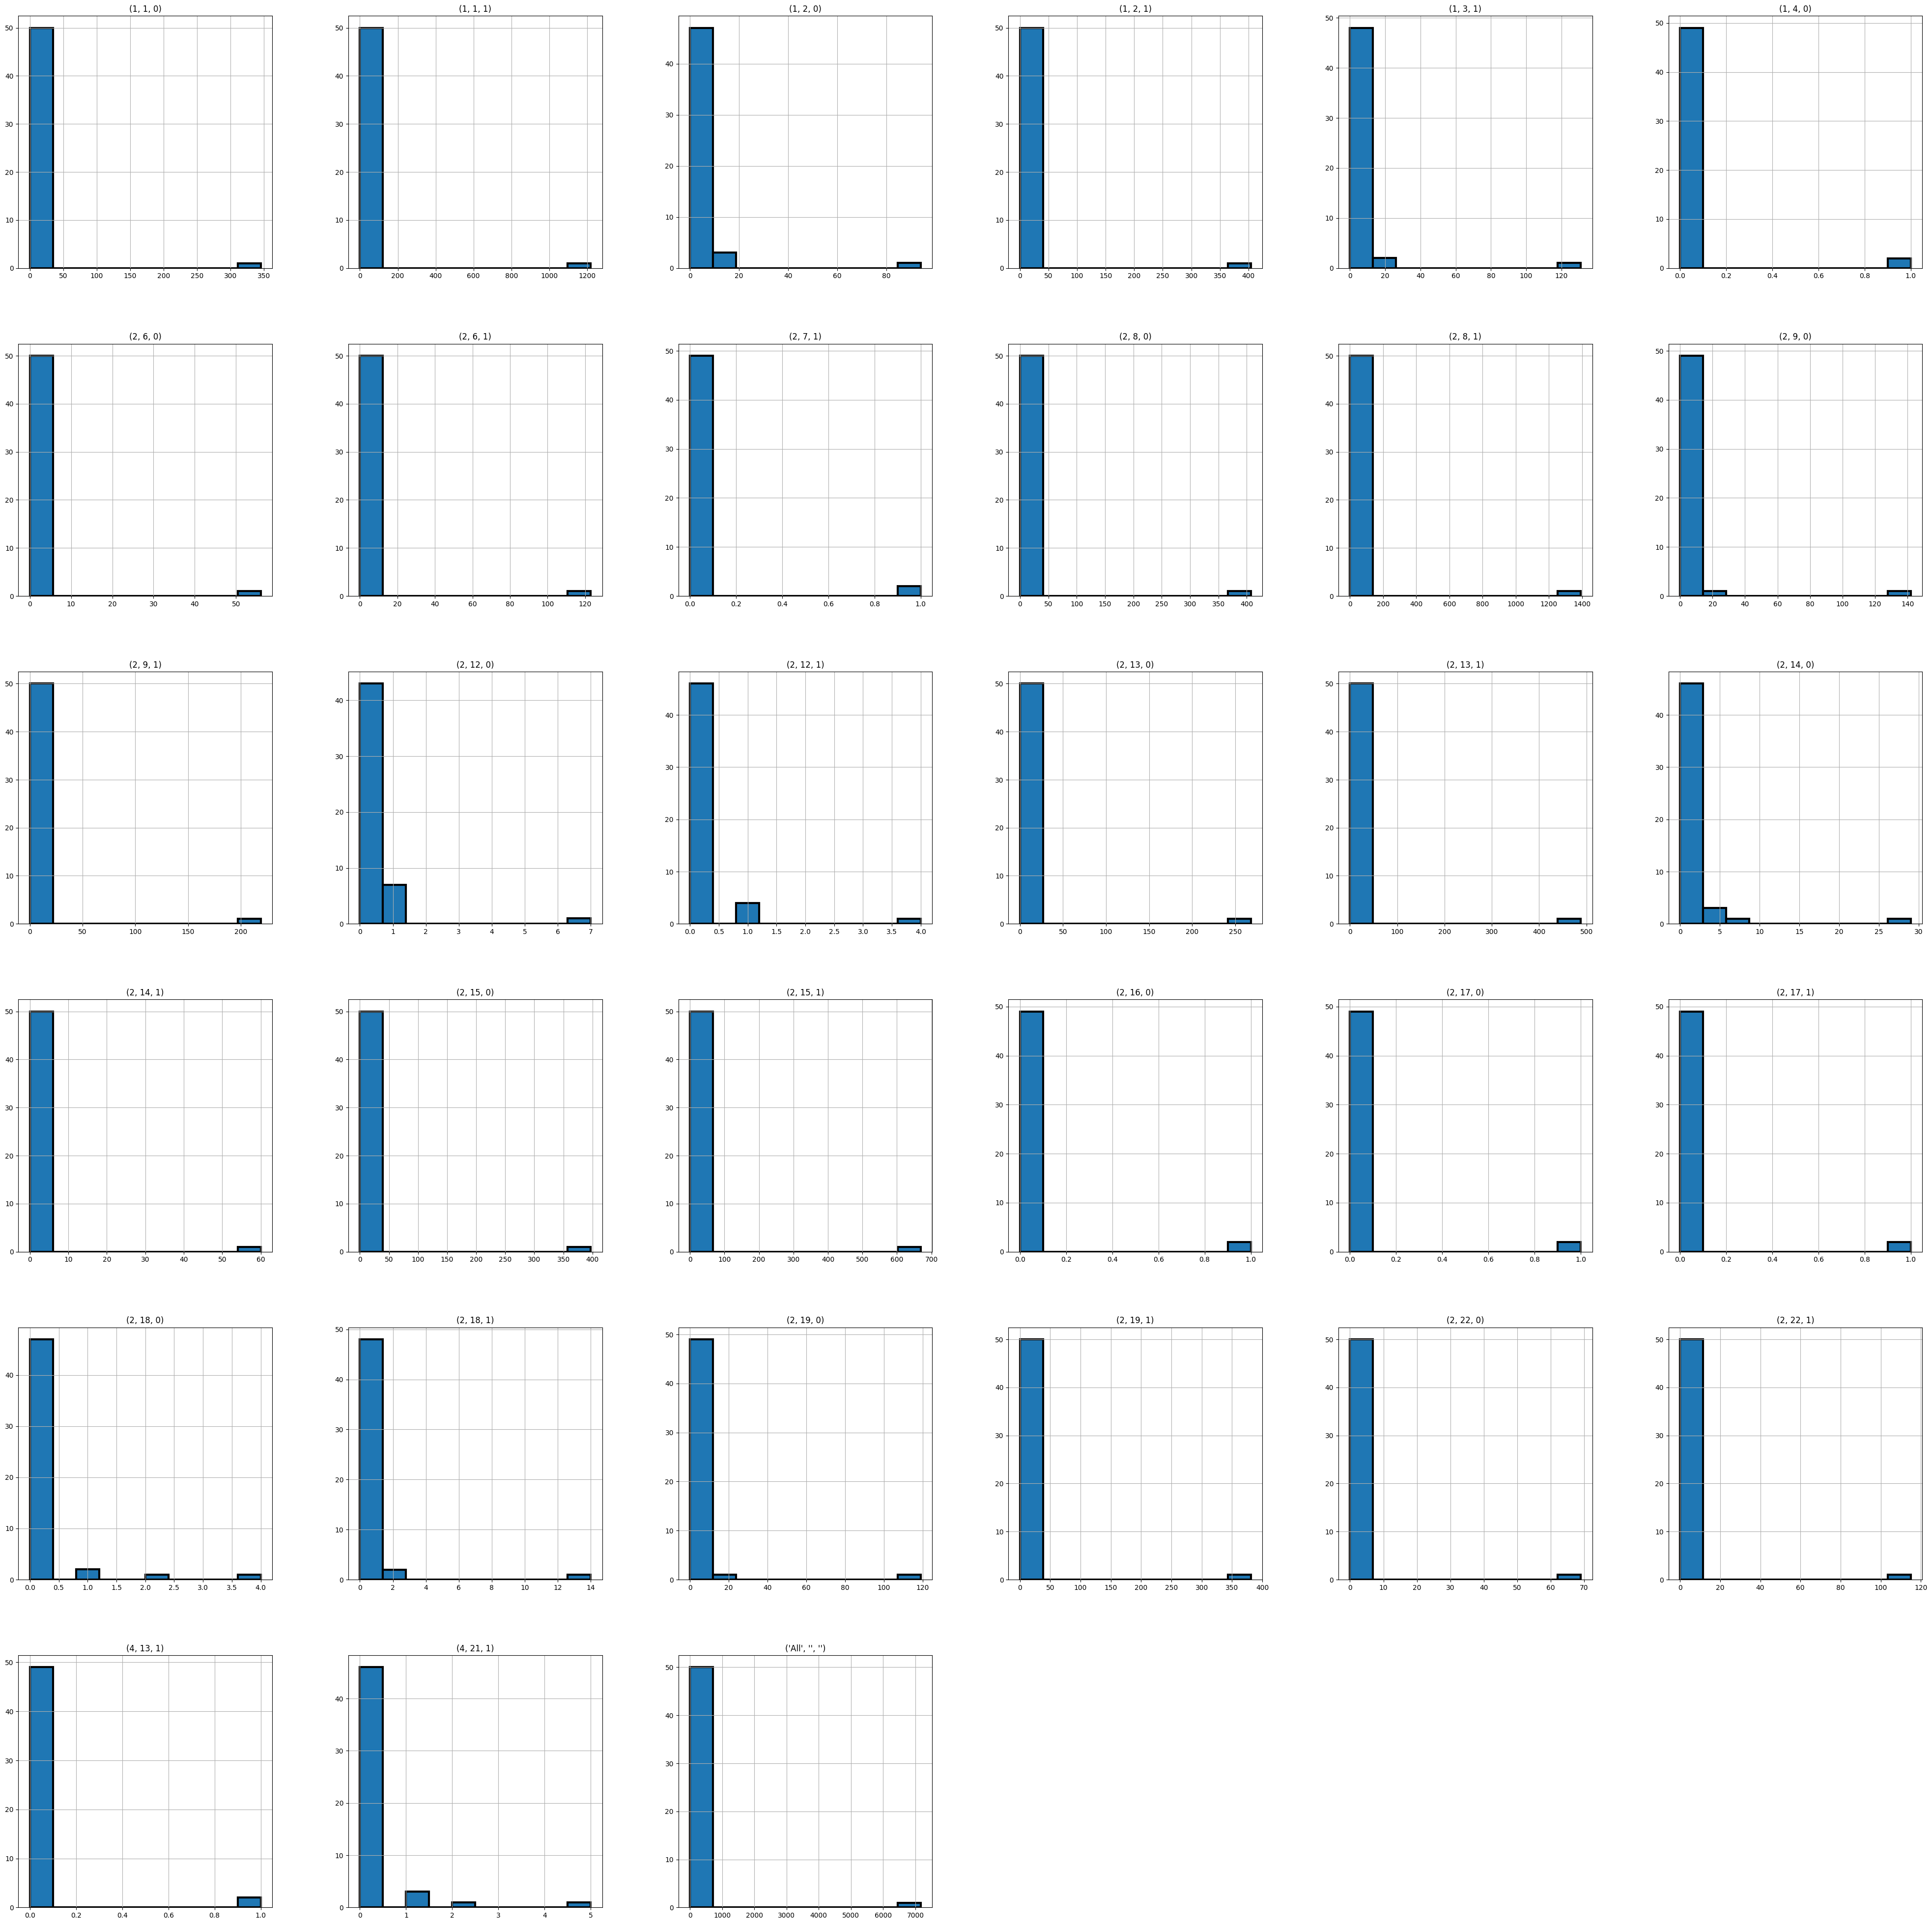

In [11]:
# Visulazing the distibution of the data for every feature
tabla_contingencia.hist(edgecolor='black', linewidth=3, figsize=(50, 50));

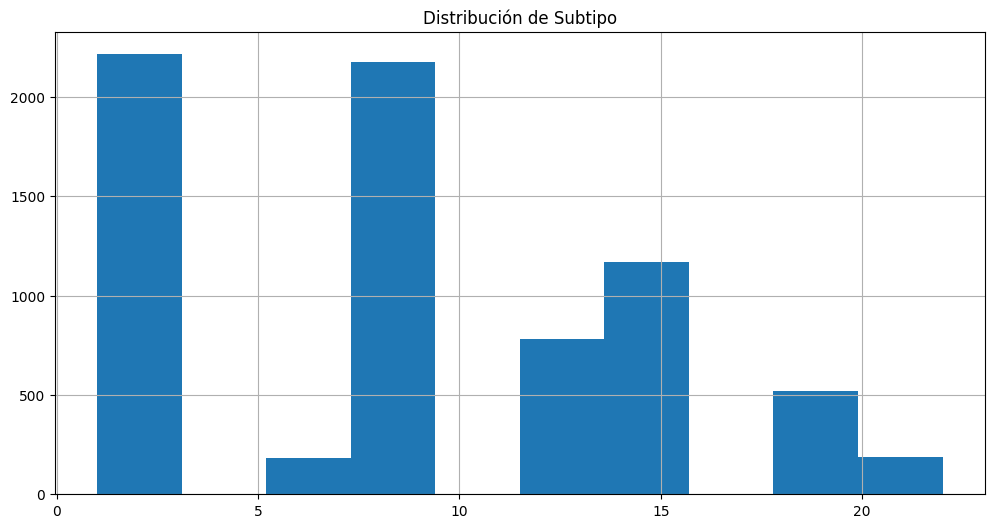

In [12]:
# histograma
ax = datos_total['SUBTIPO'].hist(figsize=(12, 6))
import matplotlib.pyplot as plt
plt.title("Distribución de Subtipo")
plt.show()


In [13]:
datos2 = datos_total[['FECHA INICIAL', 'TIPO', 'SUBTIPO', 'EDAD', 'FEMENINO', 'RANGO DE EDAD']]

In [14]:
mca = prince.MCA()
mca.fit(datos2.drop('FECHA INICIAL', axis=1).astype(str))

,n_components,2
,n_iter,10
,copy,True
,check_input,True
,random_state,None
,engine,'sklearn'
,one_hot,True
,one_hot_prefix_sep,'__'
,one_hot_columns_to_drop,None
,correction,None


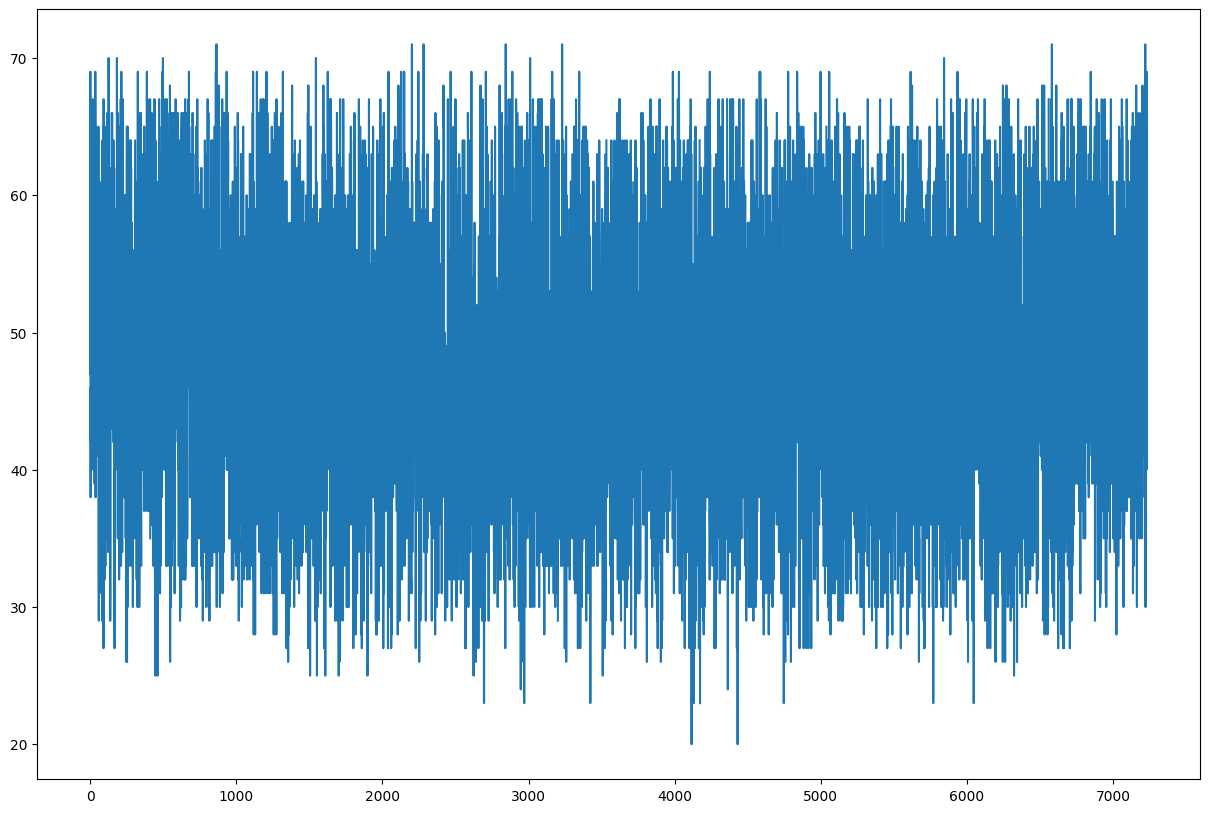

In [15]:
#graficando
ax = datos_total['EDAD'].plot(figsize=(15, 10))
ax.get_figure().savefig('edad_plot.png')


In [16]:
tabla_contingencia2 = pd.crosstab(datos_total['FECHA INICIAL'], [datos_total['EDAD'], datos_total['FEMENINO'], datos_total['RANGO DE EDAD']], margins=True)
tabla_contingencia2

EDAD                 20.0  23.0        24.0  25.0        26.0        27.0  \
FEMENINO                1     0     1     0     0     1     0     1     0   
RANGO DE EDAD       19-25 19-25 19-25 19-25 19-25 19-25 26-35 26-35 26-35   
FECHA INICIAL                                                               
2020-10-21 00:00:00     0     0     0     0     0     0     0     0     0   
2020-12-19 00:00:00     0     0     0     0     0     0     0     0     0   
2020-12-20 00:00:00     0     0     0     0     0     0     0     0     0   
2021-01-01 00:00:00     0     0     0     0     0     0     0     0     0   
2021-01-07 00:00:00     0     0     0     0     0     0     0     0     0   
...                   ...   ...   ...   ...   ...   ...   ...   ...   ...   
2022-09-19 00:00:00     0     0     0     0     0     0     0     0     0   
2022-09-20 00:00:00     0     0     0     0     0     0     0     0     0   
2022-09-21 00:00:00     0     0     0     0     0     0     0     0     0   
2022-09-28 00:00:00     0     0     0     0     0     0     0     0     0   
All                     2     6     4     2     2     9     6    16     7   

EDAD                       ... 67.0     68.0     69.0     70.0 71.0       All  
FEMENINO                1  ...    0   1    0   1    0   1    0    0   1        
RANGO DE EDAD       26-35  ...  66+ 66+  66+ 66+  66+ 66+  66+  66+ 66+        
FECHA INICIAL              ...                                                 
2020-10-21 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     1  
2020-12-19 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     1  
2020-12-20 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     1  
2021-01-01 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     1  
2021-01-07 00:00:00     0  ...    0   0    0   0    1   0    0    0   0     1  
...                   ...  ...  ...  ..  ...  ..  ...  ..  ...  ...  ..   ...  
2022-09-19 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     4  
2022-09-20 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     2  
2022-09-21 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     2  
2022-09-28 00:00:00     0  ...    0   0    0   0    0   0    0    0   0     1  
All                    41  ...   37  57    1  18   20  19    6    5   2  7167  

[530 rows x 98 columns]

In [17]:
tabla_contingencia.describe()

TIPO               1                                                  \
SUBTIPO            1                       2                       3   
FEMENINO           0            1          0           1           1   
count      51.000000    51.000000  51.000000   51.000000   51.000000   
mean       13.529412    47.803922   3.686275   15.843137    5.137255   
std        47.763732   168.287019  13.321397   56.107173   18.460790   
min         0.000000     0.000000   0.000000    0.000000    0.000000   
25%         2.500000     8.000000   0.000000    1.000000    0.000000   
50%         5.000000    25.000000   0.000000    6.000000    0.000000   
75%        11.000000    36.000000   2.500000   13.000000    6.500000   
max       345.000000  1219.000000  94.000000  404.000000  131.000000   

TIPO                         2                                     ...  \
SUBTIPO           4          6                      7           8  ...   
FEMENINO          0          0           1          1           0  ...   
count     51.000000  51.000000   51.000000  51.000000   51.000000  ...   
mean       0.039216   2.196078    4.823529   0.039216   15.960784  ...   
std        0.196039   7.789787   17.037260   0.196039   56.178630  ...   
min        0.000000   0.000000    0.000000   0.000000    0.000000  ...   
25%        0.000000   0.000000    0.500000   0.000000    4.000000  ...   
50%        0.000000   1.000000    2.000000   0.000000    7.000000  ...   
75%        0.000000   2.000000    4.000000   0.000000   11.500000  ...   
max        1.000000  56.000000  123.000000   1.000000  407.000000  ...   

TIPO                                                                          \
SUBTIPO          17         18                     19                     22   
FEMENINO          1          0          1           0           1          0   
count     51.000000  51.000000  51.000000   51.000000   51.000000  51.000000   
mean       0.039216   0.156863   0.549020    4.666667   14.941176   2.705882   
std        0.196039   0.644129   1.993125   16.551334   52.575436   9.615184   
min        0.000000   0.000000   0.000000    0.000000    0.000000   0.000000   
25%        0.000000   0.000000   0.000000    0.000000    2.000000   0.000000   
50%        0.000000   0.000000   0.000000    2.000000    9.000000   1.000000   
75%        0.000000   0.000000   0.500000    4.000000   11.000000   2.500000   
max        1.000000   4.000000  14.000000  119.000000  381.000000  69.000000   

TIPO                          4                     All  
SUBTIPO                      13         21               
FEMENINO           1          1          1               
count      51.000000  51.000000  51.000000    51.000000  
mean        4.509804   0.039216   0.196078   281.058824  
std        16.025445   0.196039   0.775103   987.013098  
min         0.000000   0.000000   0.000000     2.000000  
25%         0.000000   0.000000   0.000000    80.500000  
50%         1.000000   0.000000   0.000000   159.000000  
75%         3.500000   0.000000   0.000000   210.000000  
max       115.000000   1.000000   5.000000  7167.000000  

[8 rows x 33 columns]

## Visualizaciones Avanzadas y Vistosas
Implementación de Plotly, Altair y Bokeh para un análisis más profundo y atractivo.

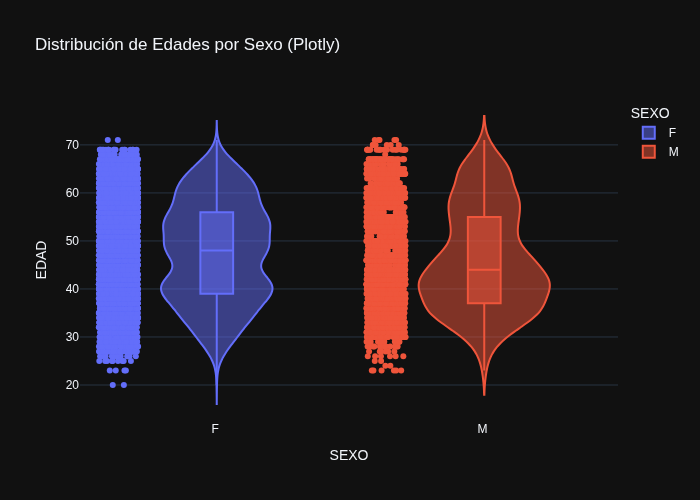

In [18]:
# 1. Plotly: Distribución Interactiva de Edades por Género
fig = px.violin(datos_total, y='EDAD', x='SEXO', color='SEXO', box=True, points='all', 
                title='Distribución de Edades por Sexo (Plotly)',
                template='plotly_dark')
fig.show()


In [19]:
# 2. Altair: Frecuencia de Subtipos
subtipo_counts = datos_total['SUBTIPO'].value_counts().reset_index()
chart = alt.Chart(subtipo_counts).mark_bar(cornerRadiusTopLeft=3, cornerRadiusTopRight=3).encode(
    x=alt.X('SUBTIPO:O', sort='-y'),
    y='count:Q',
    color=alt.Color('count:Q', scale=alt.Scale(scheme='viridis'))
).properties(title='Frecuencia de Subtipos (Altair)', width=600)
chart.display()


alt.Chart(...)

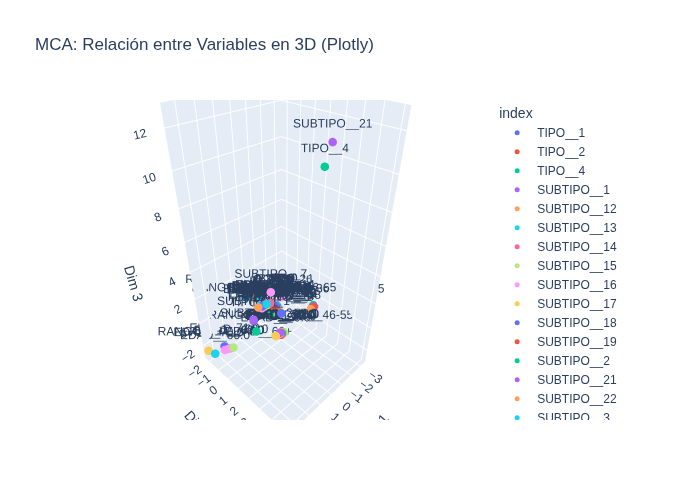

In [20]:
# 3. Plotly: Análisis de Correspondencias Múltiples (MCA) en 3D
# Usamos datos2 que ya está preparado para prince.MCA
mca_3d = prince.MCA(n_components=3)
mca_3d.fit(datos2.drop('FECHA INICIAL', axis=1).astype(str))
coords = mca_3d.column_coordinates(datos2.drop('FECHA INICIAL', axis=1).astype(str))

fig_mca = px.scatter_3d(coords, x=0, y=1, z=2, text=coords.index,
                        title='MCA: Relación entre Variables en 3D (Plotly)',
                        labels={'0': 'Dim 1', '1': 'Dim 2', '2': 'Dim 3'},
                        color=coords.index)
fig_mca.update_traces(marker=dict(size=5))
fig_mca.show()


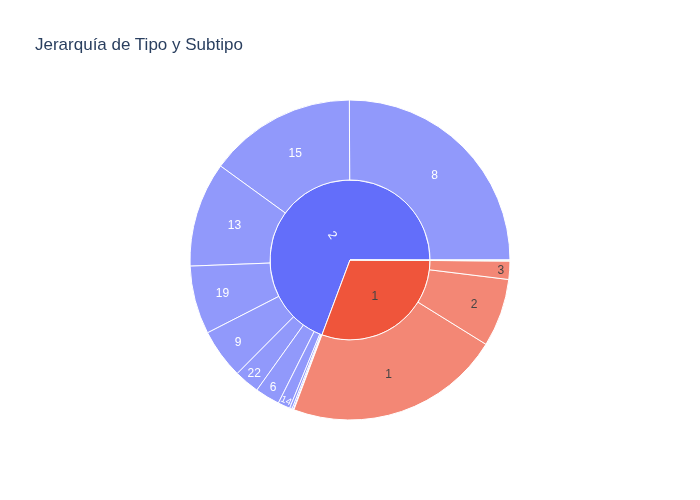

In [21]:
# 4. Plotly: Sunburst para Jerarquía de Tipo y Subtipo
fig_sun = px.sunburst(datos_total, path=['TIPO', 'SUBTIPO'], 
                      title='Jerarquía de Tipo y Subtipo',
                      color_continuous_scale='RdBu')
fig_sun.show()


## Visualizaciones Avanzadas y Vistosas
Implementación de Plotly, Altair y Bokeh para un análisis más profundo y atractivo.

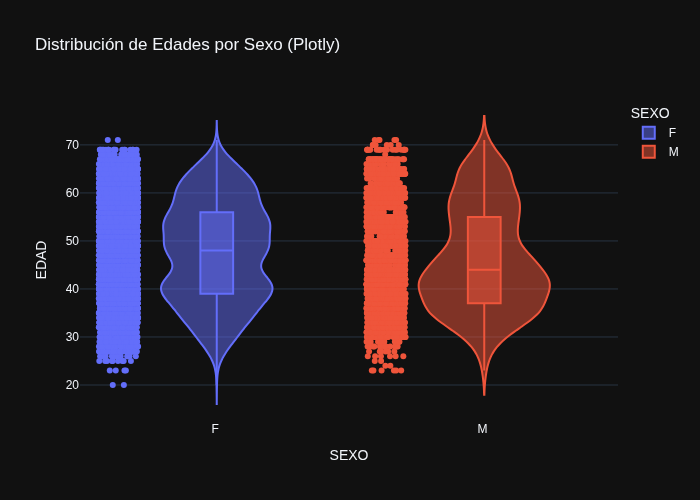

In [22]:
# 1. Plotly: Distribución Interactiva de Edades por Género
fig1 = px.violin(datos_total, y='EDAD', x='SEXO', color='SEXO', box=True, points='all', 
                title='Distribución de Edades por Sexo (Plotly)',
                template='plotly_dark')
fig1.show()


In [23]:
# 2. Altair: Frecuencia de Subtipos
subtipo_counts = datos_total['SUBTIPO'].value_counts().reset_index()
chart = alt.Chart(subtipo_counts).mark_bar(cornerRadiusTopLeft=3, cornerRadiusTopRight=3).encode(
    x=alt.X('SUBTIPO:O', sort='-y'),
    y='count:Q',
    color=alt.Color('count:Q', scale=alt.Scale(scheme='viridis'))
).properties(title='Frecuencia de Subtipos (Altair)', width=600)
try:
    chart.display()
except:
    print('Altair chart created')


alt.Chart(...)

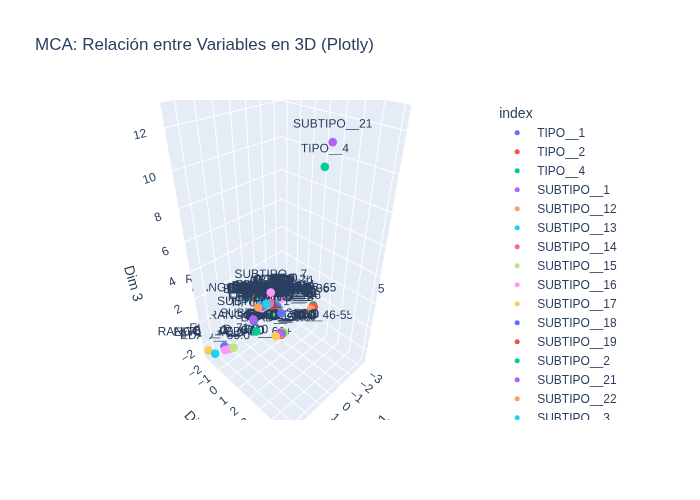

In [24]:
# 3. Plotly: Análisis de Correspondencias Múltiples (MCA) en 3D
mca_3d = prince.MCA(n_components=3)
mca_3d.fit(datos2.drop('FECHA INICIAL', axis=1).astype(str))
coords = mca_3d.column_coordinates(datos2.drop('FECHA INICIAL', axis=1).astype(str))

fig_mca = px.scatter_3d(coords, x=0, y=1, z=2, text=coords.index,
                        title='MCA: Relación entre Variables en 3D (Plotly)',
                        labels={'0': 'Dim 1', '1': 'Dim 2', '2': 'Dim 3'},
                        color=coords.index)
fig_mca.update_traces(marker=dict(size=5))
fig_mca.show()


### Visualizaciones Interactivas con Bokeh


In [25]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.transform import factor_cmap
from bokeh.palettes import Spectral6

# Preparar datos para Bokeh
counts = datos_total['SEXO'].value_counts().reset_index()
counts.columns = ['SEXO', 'count']
source = ColumnDataSource(counts)

p = figure(x_range=counts['SEXO'].tolist(), title='Distribución por Sexo (Bokeh)',
           toolbar_location=None, tools='')

p.vbar(x='SEXO', top='count', width=0.9, source=source, legend_field='SEXO',
       line_color='white', fill_color=factor_cmap('SEXO', palette=Spectral6, factors=counts['SEXO'].tolist()))

p.xgrid.grid_line_color = None
p.y_range.start = 0
p.legend.orientation = 'horizontal'
p.legend.location = 'top_center'

show(p)


# Análisis Avanzado: Clustering y Profundización MCA
En esta sección realizamos una segmentación de datos y un análisis detallado de las contribuciones de las variables.

In [26]:
# Preparación de datos para MCA profundo
cols_para_mca = ['TIPO', 'SUBTIPO', 'SEXO', 'ZONA', 'RANGO DE EDAD', 'NIVELCONTRATACION']
df_mca = datos_total[cols_para_mca].copy().astype(str)

mca_final = prince.MCA(n_components=5)
mca_final.fit(df_mca)

# Obtener coordenadas de filas (individuos)
row_coords = mca_final.row_coordinates(df_mca)
print('Coordenadas MCA calculadas.')


Coordenadas MCA calculadas.


In [27]:
# Segmentación de Usuarios (K-Means sobre MCA)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(row_coords)
datos_total['Cluster'] = clusters.astype(str)

print(f'Segmentación completada en {n_clusters} clusters.')


Segmentación completada en 4 clusters.


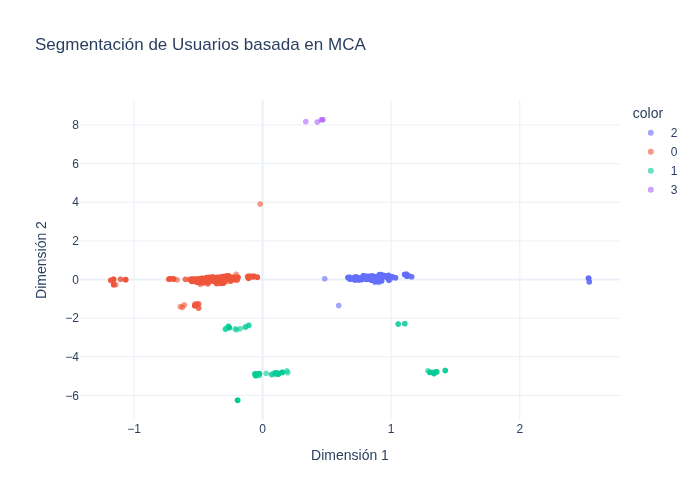

In [28]:
# Visualización de Clusters en 2D (MCA Dim 1 vs Dim 2)
fig_clusters = px.scatter(row_coords, x=0, y=1, color=datos_total['Cluster'],
                         title='Segmentación de Usuarios basada en MCA',
                         labels={'0': 'Dimensión 1', '1': 'Dimensión 2'},
                         template='plotly_white', opacity=0.6)
fig_clusters.show()


In [29]:
# Perfilado de Clusters: ¿Qué define a cada grupo?
cluster_profile = datos_total.groupby('Cluster')[['EDAD', 'TIPO', 'SUBTIPO']].agg(['mean', 'median'])
print('Perfil promedio de los clusters:')
display(cluster_profile)


Perfil promedio de los clusters:


EDAD             TIPO           SUBTIPO       
              mean median      mean median       mean median
Cluster                                                     
0        46.567094   46.0  2.000403    2.0  12.036312   13.0
1        42.655556   42.0  1.633333    2.0   8.555556    8.0
2        49.165201   50.0  1.000000    1.0   1.349221    1.0
3        52.800000   56.0  4.000000    4.0  21.000000   21.0

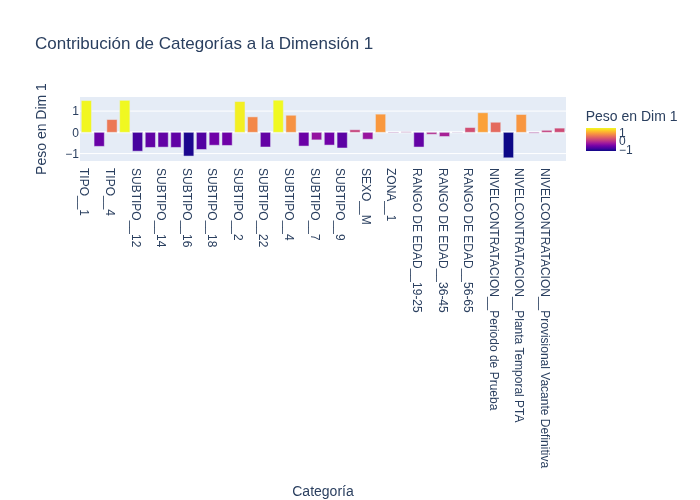

In [30]:
# Análisis de Contribuciones de Variables
col_coords = mca_final.column_coordinates(df_mca)
fig_contrib = px.bar(col_coords, y=0, x=col_coords.index, 
                     title='Contribución de Categorías a la Dimensión 1',
                     labels={'0': 'Peso en Dim 1', 'index': 'Categoría'},
                     color=col_coords[0])
fig_contrib.show()


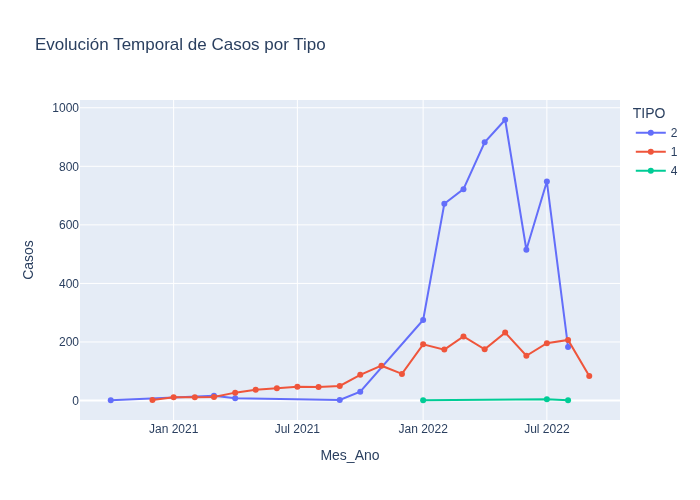

In [31]:
# Análisis Temporal: Evolución de Casos por Mes
datos_total['Mes_Ano'] = datos_total['FECHA INICIAL'].dt.to_period('M').astype(str)
temporal_trend = datos_total.groupby(['Mes_Ano', 'TIPO']).size().reset_index(name='Casos')

fig_time = px.line(temporal_trend, x='Mes_Ano', y='Casos', color='TIPO', 
                   title='Evolución Temporal de Casos por Tipo',
                   markers=True)
fig_time.show()


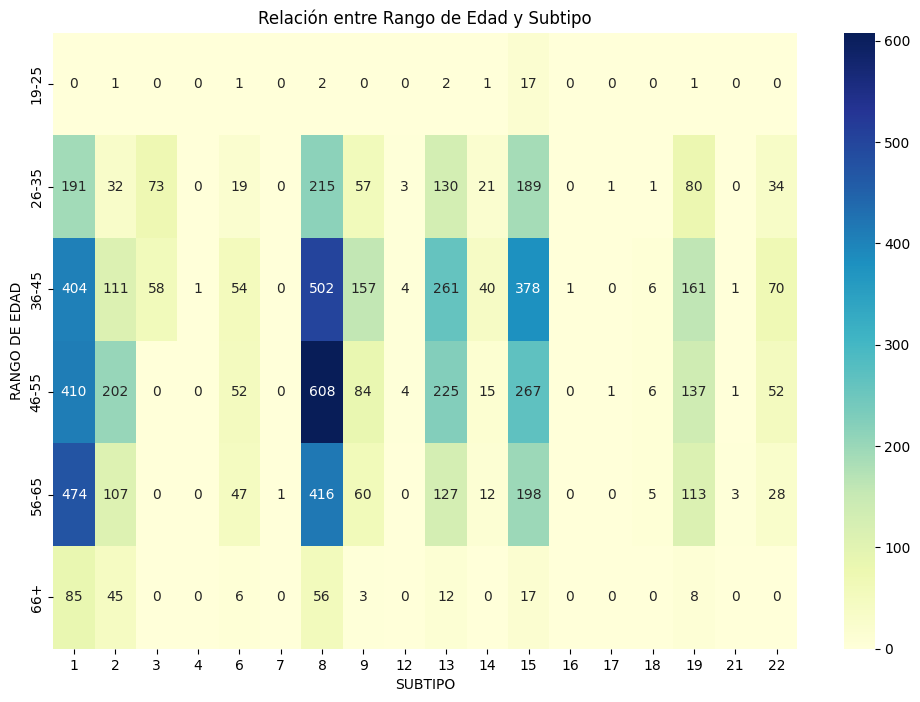

In [32]:
# Heatmap de Correlación entre Categorías (vía Cramer's V simplificado)
import seaborn as sns
plt.figure(figsize=(12, 8))
pivot_table = pd.crosstab(datos_total['RANGO DE EDAD'], datos_total['SUBTIPO'])
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Relación entre Rango de Edad y Subtipo')
plt.show()
